(12791, 9)
float64
<class 'pandas.core.frame.DataFrame'>
Index: 12745 entries, 0 to 12790
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12745 non-null  object 
 1   availability  12745 non-null  object 
 2   location      12745 non-null  object 
 3   size          12745 non-null  object 
 4   total_sqft    12745 non-null  float64
 5   bath          12745 non-null  float64
 6   balcony       12745 non-null  float64
 7   price         12745 non-null  float64
dtypes: float64(4), object(4)
memory usage: 896.1+ KB
[ 2.  5.  3.  4.  6.  1.  9.  8.  7. 11. 10. 14. 27. 12. 16. 40. 15. 13.
 18.]
19


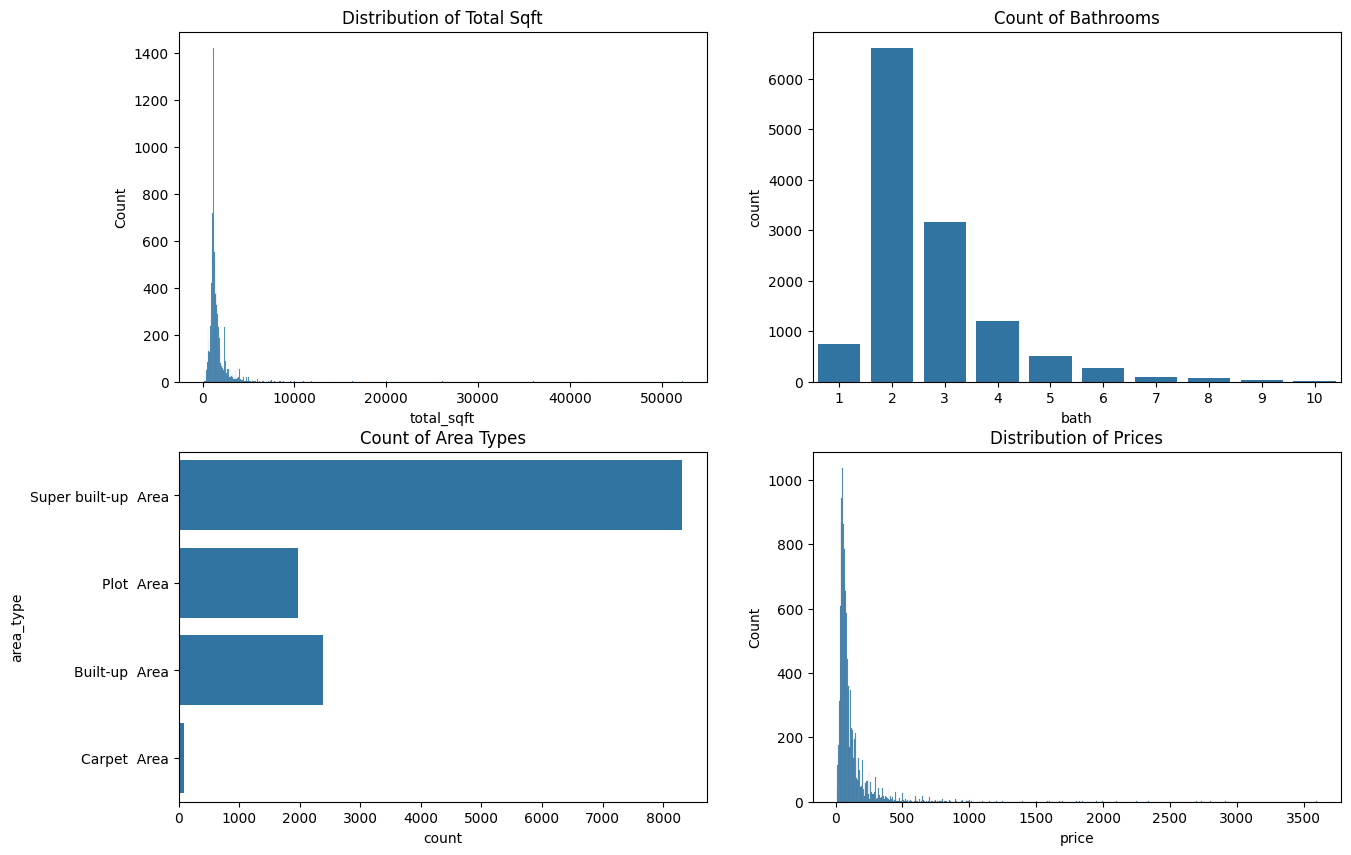

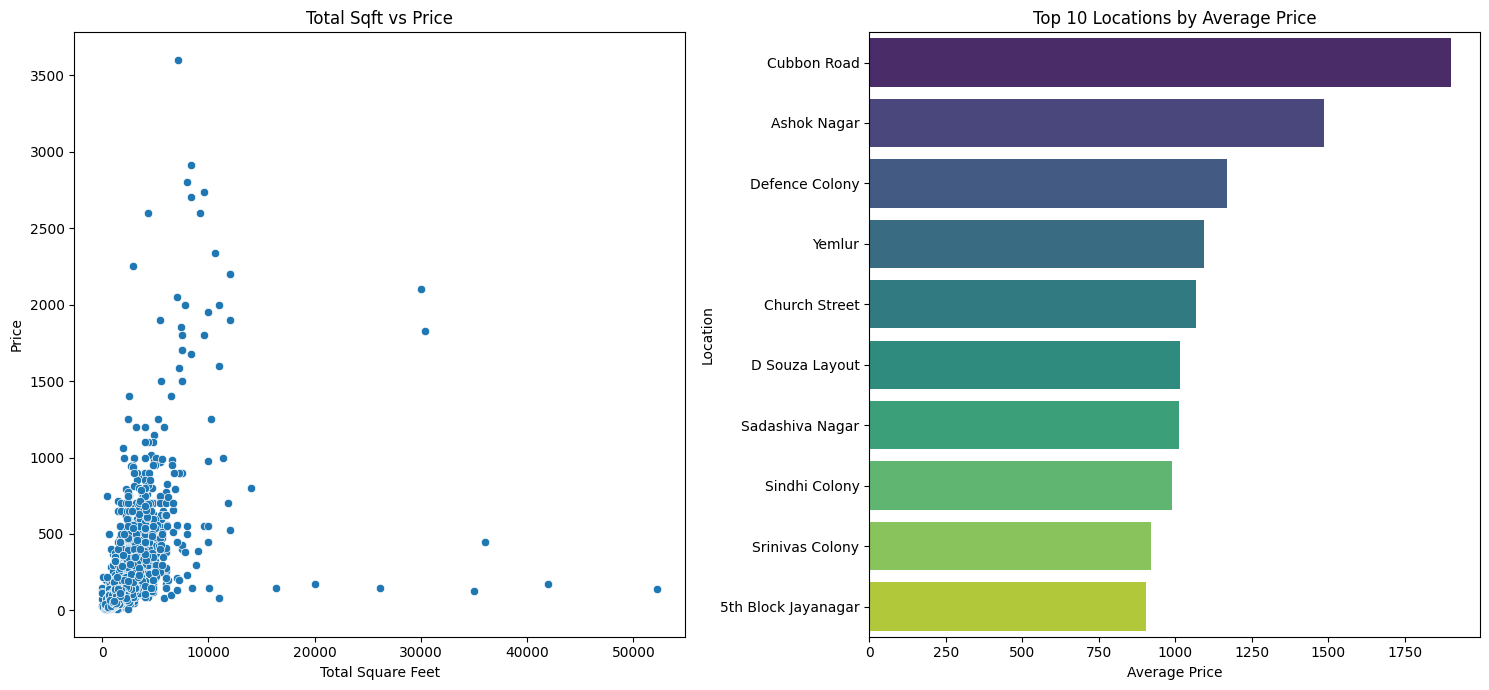

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/bengaluru_house_prices.csv')
df.head()
df.shape
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.shape)
df.drop('society',axis=1,inplace=True)


df['location'] = df['location'].fillna(df['location'].mode()[0])
df['size'] = df['size'].fillna(df['size'].mode()[0])
df['bath'] = df['bath'].fillna(df['bath'].mode()[0])
df['balcony'] = df['balcony'].fillna(df['balcony'].mode()[0])

df.isnull().sum()


df['total_sqft'].head(20)
# Check for range values like "1000 - 1200"
df[df['total_sqft'].str.contains('-')].head(10)

def convert_sqft(x):
    try:
        # if it contains '-' take average of range
        if '-' in str(x):
            parts = x.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        # otherwise just convert to float
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
print(df['total_sqft'].dtype)
df['total_sqft'].isnull().sum()

df.dropna(subset=['total_sqft'], inplace=True)
df.info()
df.isnull().sum()

df.shape
df.describe()

print(df['bath'].unique())
print(df['bath'].nunique())

df['bath'] = df['bath'].astype(int)
# Show only properties with 10 or fewer bathrooms
bath_filtered = df[df['bath'] <= 10]

#univariate
fig,axes = plt.subplots(2,2,figsize=(15,10))
sns.histplot(df['total_sqft'],ax=axes[0,0])
sns.countplot(data=bath_filtered, x='bath',ax=axes[0,1])
sns.countplot(df['area_type'],ax=axes[1,0])
sns.histplot(df['price'],ax=axes[1,1])

axes[0,0].set_title('Distribution of Total Sqft')
axes[0,1].set_title('Count of Bathrooms')
axes[1,0].set_title('Count of Area Types')
axes[1,1].set_title('Distribution of Prices')
plt.show()

# bivariate
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Scatterplot: total_sqft vs price
sns.scatterplot(x='total_sqft', y='price', data=df, ax=axes[0])
axes[0].set_title('Total Sqft vs Price')
axes[0].set_xlabel('Total Square Feet')
axes[0].set_ylabel('Price')

# Top 10 locations by average price
top_10_locations = df.groupby('location')['price'].mean().nlargest(10).reset_index()

# Bar plot for top 10 locations by average price
sns.barplot(x='price', y='location', hue='location', data=top_10_locations, palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Top 10 Locations by Average Price')
axes[1].set_xlabel('Average Price')
axes[1].set_ylabel('Location')

plt.tight_layout()
plt.show()